# Task 2.1

## Transition Probability for the Ramp Model

### 1. Without Boundary Condition

The ramp model update rule is:

$$
x_{t+1} = x_t + \beta \, dt + \sigma \sqrt{dt} \, \epsilon_t, \quad \epsilon_t \sim \mathcal{N}(0, 1)
$$

So the conditional distribution of $x_{t+1}$ given $x_t$ is:

$$
x_{t+1} \mid x_t \sim \mathcal{N}(x_t + \beta dt,\; \sigma^2 dt)
$$

And the transition probability density is:

$$
P(x_{t+1} \mid x_t) = \frac{1}{\sqrt{2\pi \sigma^2 dt}} \exp\left( -\frac{(x_{t+1} - x_t - \beta dt)^2}{2\sigma^2 dt} \right)
$$

(Same as parker so far)

---

### 2. With Boundary Condition at $x = 0$

Now we enforce that $x_t \geq 0$ always. If a proposed update takes $x_t$ below 0, it is instead clipped at 0:

$$
x_{t+1} = \max\left(0,\; x_t + \beta dt + \sigma \sqrt{dt} \, \epsilon_t \right)
$$

i.e.

$$
x_{t+1} = \max\left(0,\; x_{t+1} \right)
$$

This modifies the transition distribution:

---

#### Case A: $x_t > 0$

We still use the normal distribution:


$$
x_{t+1} \mid x_t > 0 \sim \mathcal{N}(x_t + \beta dt,\; \sigma^2 dt)
$$

But to strictly enforce $x_{t+1} \geq 0$, we redefine it as a **truncated Gaussian** on $x > 0$, plus a point mass at 0:

- Probability of hitting zero:

$$
P(x_{t+1} = 0 \mid x_t) = \Phi\left( -\frac{x_t + \beta dt}{\sigma \sqrt{dt}} \right)
$$

- Density for $x_{t+1} > 0$:

$$
P(x_{t+1} = x \mid x_t,\; x > 0) = \frac{1}{\sigma \sqrt{2\pi dt}} \cdot \frac{\exp\left(-\frac{(x - x_t - \beta dt)^2}{2 \sigma^2 dt}\right)}{1 - \Phi\left(-\frac{x_t + \beta dt}{\sigma \sqrt{dt}} \right)}
$$

---

#### Case B: $x_t = 0$

Now the process starts at the boundary. Define:

$$
\mu = \beta dt, \quad \sigma^2 = \sigma^2 dt
$$

Let $Z \sim \mathcal{N}(\mu, \sigma^2)$. Then:

- Probability of remaining at zero:

$$
P(x_{t+1} = 0 \mid x_t = 0) = \Phi\left( -\frac{\mu}{\sigma} \right) = \Phi\left( -\frac{\beta \sqrt{dt}}{\sigma} \right)
$$

- Probability density for $x_{t+1} > 0$:

$$
P(x_{t+1} = x \mid x_t = 0, x > 0) = \frac{1}{\sigma \sqrt{2\pi dt}} \cdot \frac{\exp\left( -\frac{(x - \beta dt)^2}{2\sigma^2 dt} \right)}{\Phi\left( \frac{\beta \sqrt{dt}}{\sigma} \right)}
$$

This is a **truncated Gaussian** distribution, normalized over the positive half-line, with a point mass at 0.

$$
P(x_{t+1}|x_t) = \begin{cases}P(x_{t+1} = x \mid x_t = 0) = \frac{1}{\sigma \sqrt{2\pi dt}} \cdot \exp\left( -\frac{(x - \beta dt)^2}{2\sigma^2 dt} \right) & \text{if } x > 0 \\
P(x_{t+1} = 0 \mid x_t = 0) = \Phi\left( -\frac{\mu}{\sigma} \right) = \Phi\left( -\frac{\beta \sqrt{dt}}{\sigma} \right) & \text{if } x_t=0 \text{ and } x_t \geq 0 \\
0 & \text{if } x_{t+1} < 0
\end{cases}
$$
---

### Summary

The full transition probability with boundary at $x = 0$ is a **mixture of**:
- A **point mass at 0**: if the noise would push $x_{t+1}$ negative,
- A **truncated Gaussian**: if the proposed update remains positive,

This ensures that $x_t \geq 0$ for all $t$, while preserving the original stochastic ramp dynamics.


### Integral Form of the Cumulative Distribution Function

For full form of the stuff above, the standard Gaussian CDF is:

$$
\Phi(z) = \int_{-\infty}^{z} \frac{1}{\sqrt{2\pi}} \, e^{-u^2/2} \, du
$$

#### For the transition probability:

When $ x_t > 0 $, the probability that the proposed update falls below 0 (and is thus clipped) is:

$$
P(x_{t+1} = 0 \mid x_t) = \Phi\left( -\frac{x_t + \beta dt}{\sigma \sqrt{dt}} \right) 
= \int_{-\infty}^{-\frac{x_t + \beta dt}{\sigma \sqrt{dt}}} \frac{1}{\sqrt{2\pi}} e^{-u^2/2} \, du
$$

#### When $ x_t = 0 $ :

Then the probability that $ x_{t+1} = 0 $ (i.e., that the Gaussian sample is negative) becomes:

$$
P(x_{t+1} = 0 \mid x_t = 0) = \Phi\left( -\frac{\beta \sqrt{dt}}{\sigma} \right)
= \int_{-\infty}^{-\frac{\beta \sqrt{dt}}{\sigma}} \frac{1}{\sqrt{2\pi}} e^{-u^2/2} \, du
$$

This is the same as $ x_t > 0 $ just good to highlight. When $ x_t > 0 $, due to the variance relying on $dt$, which is small, we may not need to consider the truncated part of the distribution, as it is likely far enough away to have an effect.

### Transition Probabilities $P(x_{t+1} \mid x_t)$

Let:
- $\mu = x_t + \beta \, dt$
- $\sigma^2 = \sigma^2 \, dt$
- $\phi(x; \mu, \sigma^2)$: Gaussian PDF with mean $\mu$, variance $\sigma^2$
- $\Phi(0; \mu, \sigma^2)$: Gaussian CDF evaluated at 0

Then:

$$
P(x_{t+1} \mid x_t) =
\begin{cases}
\Phi(0; \beta dt, \sigma^2 dt) \cdot \delta(x_{t+1}) + \dfrac{\phi(x_{t+1}; \beta dt, \sigma^2 dt)}{1 - \Phi(0; \beta dt, \sigma^2 dt)} \cdot \mathbb{1}_{x_{t+1} > 0} & \text{if } x_t = 0 \\\\
\phi(x_{t+1}; x_t + \beta dt, \sigma^2 dt) & \text{if } x_t > 0
\end{cases}
$$

where

$$
\mathbb{1}_{x_{t+1} > 0} = 
\begin{cases}
1 & \text{if } x_{t+1} > 0 \\
0 & \text{otherwise}
\end{cases}
$$

It **equals 1 when the condition is true** and **0 otherwise**.

**Interpretation**:
- If $x_t = 0$: 
  - There is a point mass at $x_{t+1} = 0$ with probability $\Phi(0; \beta dt, \sigma^2 dt)$
  - The rest is a truncated Gaussian over $x_{t+1} > 0$
- If $x_t > 0$: 
  - The update is a standard Gaussian with mean $x_t + \beta dt$ and variance $\sigma^2 dt$
- If accuracy is required over coding simplicity, we can ignore the $x_t > 0$ case and just say for all $x_t \geq 0$


### Implementing absorbing boundary condition ###

As when $x_t$ = 1 it stays there, we need to also account for this

$$
P(x_{t+1} \mid x_t) =
\begin{cases}
\delta(x_{t+1} - 1) & \text{if } x_t = 1 \\
\\
\Phi(0; \mu, \sigma^2) \cdot \delta(x_{t+1}) + \left[ \dfrac{\phi(x_{t+1}; \mu, \sigma^2)}{\Phi(1; \mu, \sigma^2) - \Phi(0; \mu, \sigma^2)} \right] \cdot \mathbb{1}_{(0 < x_{t+1} < 1)} + (1 - \Phi(1; \mu, \sigma^2)) \cdot \delta(x_{t+1} - 1) & \text{if } x_t = 0 \\
\\
\left[ \dfrac{\phi(x_{t+1}; \mu, \sigma^2)}{\Phi(1; \mu, \sigma^2) - \Phi(0; \mu, \sigma^2)} \right] \cdot \mathbb{1}_{(0 < x_{t+1} < 1)} + \Phi(0; \mu, \sigma^2) \cdot \delta(x_{t+1}) + (1 - \Phi(1; \mu, \sigma^2)) \cdot \delta(x_{t+1} - 1) & \text{if } 0 < x_t < 1 \\
\end{cases}
$$


# Task 2.1 Plan: Forming an HMM Approximation to the Ramp Model

This plan outlines the steps to approximate the continuous ramp model using a discrete-state Hidden Markov Model (HMM).

---

## 1. Understand the Continuous Model

We start with the continuous update rule:

$$
x_{t+1} = x_t + \beta\,dt + \sigma\sqrt{dt}\,\epsilon_t, \quad \epsilon_t \sim \mathcal{N}(0,1)
$$

### Boundary Conditions:
- Reflecting at $x = 0$: If a negative update would take $x_t < 0$, we clamp it to zero.
- Absorbing at $x = 1$: Once $x_t = 1$, it stays there forever.

---

## 2. Discretize the State Space

Discretize $x \in [0, 1]$ into $K$ evenly spaced points:

```python
K = 100
x_vals = np.linspace(0, 1, K)
```

Each state index $s \in \{0, \ldots, K-1\}$ corresponds to:

$$
x_s = \frac{s}{K-1}
$$

---

## 3. Build the Transition Matrix $\mathcal{T}_{s,s'}$

For each pair $(s, s')$:

1. Compute the mean and standard deviation:

$$
\mu = x_s + \beta\,dt, \quad \text{std} = \sigma\sqrt{dt}
$$

2. Define bin width:

$$
\delta = \frac{1}{K-1}
$$

3. Compute transition probabilities using the Gaussian CDF:

$$
\mathcal{T}_{s, s'} = \int_{x_{s'} - \delta/2}^{x_{s'} + \delta/2} \mathcal{N}(x; \mu, \sigma^2 dt)\,dx
$$

### Special Cases:
- **Reflecting at 0**:

$$
\mathcal{T}_{0, 0} += \int_{-\infty}^{0} \mathcal{N}(x; \mu, \sigma^2 dt)\,dx
$$

- **Absorbing at 1**:

$$
\mathcal{T}_{K-1, K-1} = 1, \quad \mathcal{T}_{K-1, s'} = 0 \text{ for } s' \ne K-1
$$

---

## 4. Normalize Rows

Ensure each row of $\mathcal{T}$ sums to 1:

```python
T = T / T.sum(axis=1, keepdims=True)
```

For numerical stability (if needed), compute in log-space using `scipy.special.logsumexp`.

---

## 5. Construct the Initial Distribution $\pi$

Given:

$$
x_0 = x_{\text{init}} + \sigma\sqrt{dt} \epsilon_0
$$

Create a Gaussian over the $x$-grid:

```python
pi = norm.pdf(x_vals, loc=x_init, scale=sigma * np.sqrt(dt))
pi /= pi.sum()
```

---

## 6. Simulate the Markov Chain

1. Draw initial state:

```python
s_0 = np.random.choice(K, p=pi)
```

2. Iterate:

```python
s_t = np.random.choice(K, p=T[s_prev])
x_t = x_vals[s_t]
```

3. Repeat for desired number of time steps.

---

## 7. Compute Firing Rate

Map $x_t$ to firing rate:

$$
r_t = r_0 + (r_{\text{max}} - r_0)x_t
$$

Compare to continuous ramp model’s firing rate to validate approximation.

---

## 8. Check for Stuck Trajectories

If $\sigma$ is too small (especially when $\beta = 0$), updates may not be large enough to change state.

Estimate the threshold:

$$
\sigma_{\text{min}} \sim \frac{\delta}{\sqrt{dt}} = \frac{1}{(K - 1)\sqrt{dt}}
$$

Use values of $\sigma$ above this threshold unless instructed otherwise.

---

## Summary

By following these steps, you will:

- Discretize the latent space of the ramp model
- Form an HMM transition matrix under boundary constraints
- Simulate HMM trajectories and compare them to the original model
- Analyze how model parameters affect dynamics and convergence

```python
# Optional: numpy/sciPy tools you'll use
import numpy as np
from scipy.stats import norm
from scipy.special import logsumexp
```


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

class DiscreteRampHMM:
    def __init__(self, beta, sigma, dt, K, x0):
        self.beta = beta
        self.sigma = sigma
        self.dt = dt
        self.K = K
        self.x0 = x0
        self.grid = np.linspace(0, 1, K)
        self.T = self._build_transition_matrix()
        self.pi = self._build_initial_distribution()

    def _truncated_normal_pdf(self, x, mu, sigma, lower, upper):
        Z = norm.cdf(upper, loc=mu, scale=sigma) - norm.cdf(lower, loc=mu, scale=sigma)
        return norm.pdf(x, loc=mu, scale=sigma) / Z if Z > 0 else 0.0

    def _gaussian_cdf(self, x, mu, sigma):
        return norm.cdf(x, loc=mu, scale=sigma)

    def _build_transition_matrix(self):
        T = np.zeros((self.K, self.K))
        for s in range(self.K):
            x = self.grid[s]
            mu = x + self.beta * self.dt
            std = self.sigma * np.sqrt(self.dt)

            if x >= 1.0:
                T[s, -1] = 1.0
                continue

            for s_prime in range(self.K):
                x_next = self.grid[s_prime]
                if x > 0:
                    T[s, s_prime] = self._truncated_normal_pdf(x_next, mu, std, 0, 1)
                else:
                    if x_next == 0:
                        T[s, s_prime] = self._gaussian_cdf(0, mu, std)
                    else:
                        T[s, s_prime] = self._truncated_normal_pdf(x_next, mu, std, 0, 1)

            row_sum = T[s].sum()
            if row_sum > 0:
                T[s] /= row_sum
            else:
                T[s, s] = 1.0  # Fallback to identity if all probabilities are 0

        return T

    def _build_initial_distribution(self):
        mu = self.x0
        std = self.sigma * np.sqrt(self.dt)
        pi = np.array([self._truncated_normal_pdf(x, mu, std, 0, 1) for x in self.grid])
        return pi / pi.sum()

    def plot_transition_matrix(self):
        plt.figure(figsize=(8, 6))
        sns.heatmap(self.T, cmap="viridis", cbar=True, square=True)
        plt.title("Transition Matrix Heatmap")
        plt.xlabel("Next state $s'$")
        plt.ylabel("Current state $s$")
        plt.tight_layout()
        plt.show()

    def plot_initial_distribution(self):
        plt.figure(figsize=(8, 4))
        plt.plot(self.grid, self.pi, drawstyle='steps-mid')
        plt.title("Initial State Distribution $\pi$")
        plt.xlabel("$x$")
        plt.ylabel("Probability")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def simulate_trajectory(self, T_steps):
        s_t = np.random.choice(self.K, p=self.pi)
        trajectory = [self.grid[s_t]]
        for _ in range(T_steps - 1):
            s_t = np.random.choice(self.K, p=self.T[s_t])
            trajectory.append(self.grid[s_t])
        return np.array(trajectory)


<>:71: SyntaxWarning: invalid escape sequence '\p'
<>:71: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_94523/2784363170.py:71: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Initial State Distribution $\pi$")


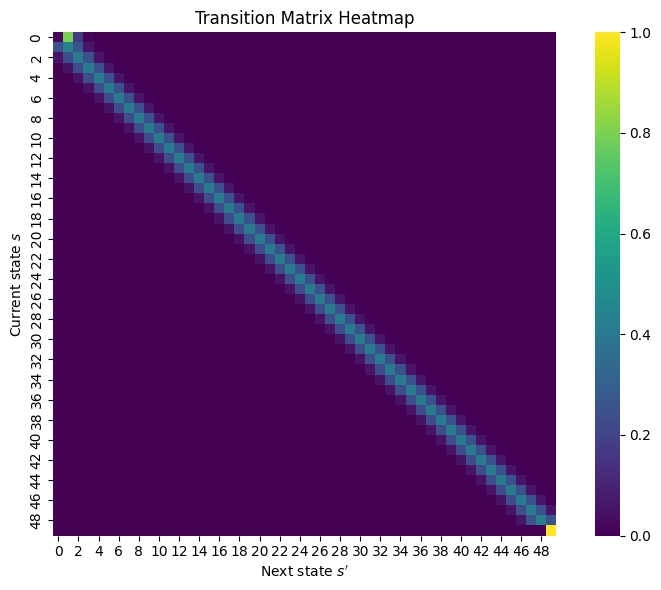

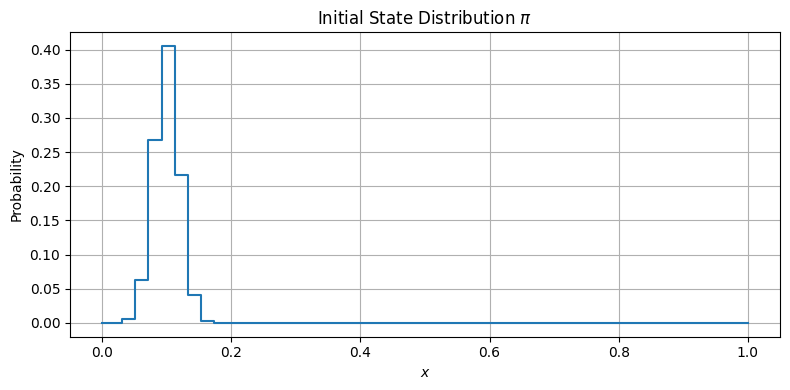

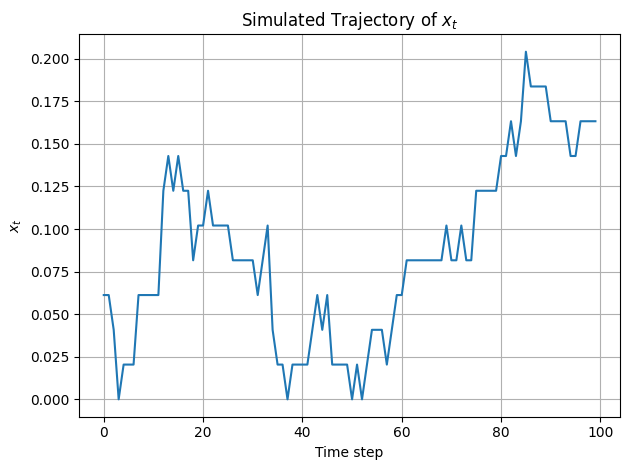

In [19]:
if __name__ == "__main__":
    hmm = DiscreteRampHMM(beta=0.05, sigma=0.2, dt=0.01, K=50, x0=0.1)
    hmm.plot_transition_matrix()
    hmm.plot_initial_distribution()

    traj = hmm.simulate_trajectory(T_steps=100)
    plt.figure()
    plt.plot(traj)
    plt.title("Simulated Trajectory of $x_t$")
    plt.xlabel("Time step")
    plt.ylabel("$x_t$")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Seems to be an issue with the top left state transition but will look at later. Still need to double check some stuff. 

Edit: Ah put x0 as non zero coz I am a melon

Another edit - still top left one looks suspiciously low

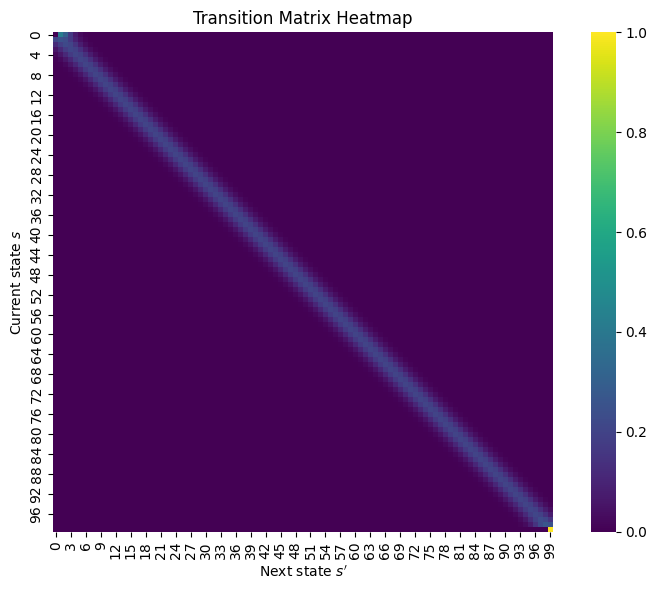

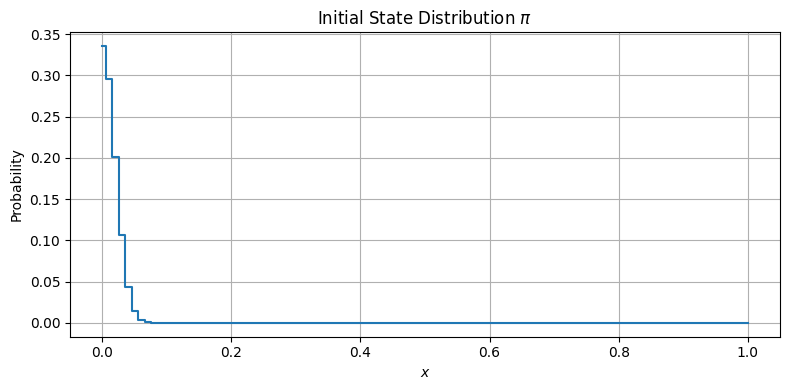

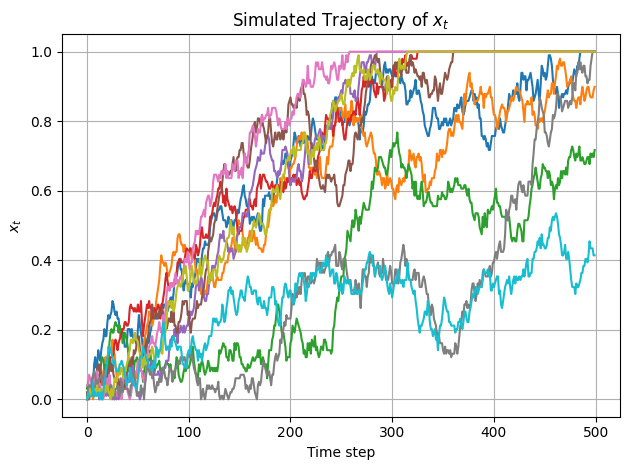

In [20]:
#### Multiple sims done to show variation of results

if __name__ == "__main__":
    hmm = DiscreteRampHMM(beta=0.2, sigma=0.2, dt=0.01, K=100, x0=0)
    hmm.plot_transition_matrix()
    hmm.plot_initial_distribution()
    plt.figure()
    for i in range(10):
        traj = hmm.simulate_trajectory(T_steps=500)
        plt.plot(traj)
    plt.title("Simulated Trajectory of $x_t$")
    plt.xlabel("Time step")
    plt.ylabel("$x_t$")
    plt.grid(True)
    plt.tight_layout()
    plt.show()



# Task 2.2

## Task 2.2 Theory: HMM Approximation of the Step Model

The **step model** describes a latent variable $ x_t $ that takes **binary values**, corresponding to low and high firing rate levels. It stays at the low level for a random time, then makes a transition to the high level (a “step”), and then remains there.

Because the latent variable can only take two values (0 and 1), we can represent this as a **discrete-state Hidden Markov Model (HMM)** with:
- **State space:** $ s_t \in \{0, 1\} $
- **Transition matrix:** A 2×2 matrix $ \mathcal{T} $

---

### Initial (Inexact) 2-State HMM

We start with a **2-state time-homogeneous** HMM, meaning transition probabilities do not change over time.

Let the transition matrix be:
$$
\mathcal{T} = \begin{bmatrix}
1 - p & p \\
0 & 1
\end{bmatrix}
$$

This models the idea that once you reach state 1, you **stay there forever**, while in state 0 you make a geometric transition to state 1 with probability $ p $.

#### Choosing $ p $

If the step time follows a Negative Binomial (NB) distribution:
- NB models the number of **failures before r successes**, with parameter $ p = \frac{r}{m + r} $ where:
  - $ m $: mean
  - $ r $: shape (integer)

For the **Geometric distribution**, which is a special case of NB with $ r = 1 $, this becomes:
$$
p = \frac{1}{m + 1}
$$

---

### ✅ Improved: Exact HMM with $ r + 1 $ States

To exactly match the NB($ m, r $) distribution for the **step time**, construct a Markov chain with  $r + 1$  states:

- States: $ \{0, 1, 2, \dots, r\} $
- Final state $ r $: absorbing (represents step complete)
- Transition probabilities arranged such that the time to reach state $ r $ matches NB-distributed steps

---

## Task Plan

### Step 1: Theory and Parameters
- Understand Geometric vs Negative Binomial distributions
- Choose $ p $ based on $ m $ and $ r $

### Step 2: Create 2-State HMM Class
- States: 0 (pre-step), 1 (post-step)
- Transition matrix with parameter $ p $
- Simulate multiple trajectories of $ x_t $
- Plot step transitions
- Plot histogram of jump times (time spent in state 0)

### Step 3: Create Exact HMM with $ r + 1 $ States
- Transition matrix with deterministic rightward transitions and probabilistic stay
- Final state is absorbing
- Simulate and plot as above

### Step 4: Comparison
- Compare histograms of jump times between:
  - 2-state HMM
  - Exact NB HMM
  - Original Week 1 model


In [21]:
import numpy as np
import matplotlib.pyplot as plt


class StepModelHMM:
    def __init__(self, m, r=1, T=100, dt=1.0, exact=False):
        """
        m: mean of the NB distribution
        r: shape parameter of NB (r=1 is geometric)
        T: number of time steps
        dt: timestep size
        exact: whether to use exact NB model (with r+1 states)
        """
        self.m = m
        self.r = r
        self.T = T
        self.dt = dt
        self.exact = exact
        self.p = r / (m + r)
        self.K = r + 1 if exact else 2  # number of states
        self.T_matrix = self._build_transition_matrix()

    def _build_transition_matrix(self):
        T = np.zeros((self.K, self.K))
        if self.exact:
            for i in range(self.K - 1):
                T[i, i] = 1 - self.p
                T[i, i + 1] = self.p
            T[-1, -1] = 1.0  # absorbing state
        else:
            T[0, 0] = 1 - self.p
            T[0, 1] = self.p
            T[1, 1] = 1.0
        return T

    def simulate(self, n_trials=10):
        all_trajectories = []
        all_jump_times = []

        for _ in range(n_trials):
            s = 0
            traj = [s]
            jump_time = None

            for t in range(1, self.T):
                s = np.random.choice(self.K, p=self.T_matrix[s])
                traj.append(s)
                if not self.exact and s == 1 and jump_time is None:
                    jump_time = t
                elif self.exact and s == self.r and jump_time is None:
                    jump_time = t

            all_trajectories.append(traj)
            all_jump_times.append(jump_time if jump_time is not None else self.T)

        return np.array(all_trajectories), np.array(all_jump_times)

    def plot_trajectories(self, trajectories):
        for traj in trajectories:
            plt.plot(np.arange(len(traj)) * self.dt, traj)
        plt.xlabel("Time")
        plt.ylabel("State")
        plt.title("Step Model Trajectories")
        plt.grid()
        plt.show()

    def plot_jump_histogram(self, jump_times):
        plt.hist(jump_times * self.dt, bins=20, edgecolor='black')
        plt.xlabel("Jump Time")
        plt.ylabel("Count")
        plt.title("Histogram of Jump Times")
        plt.grid()
        plt.show()




=== Two-State HMM ===


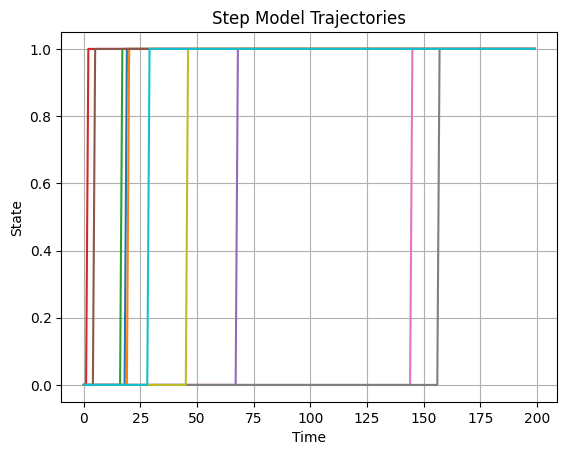

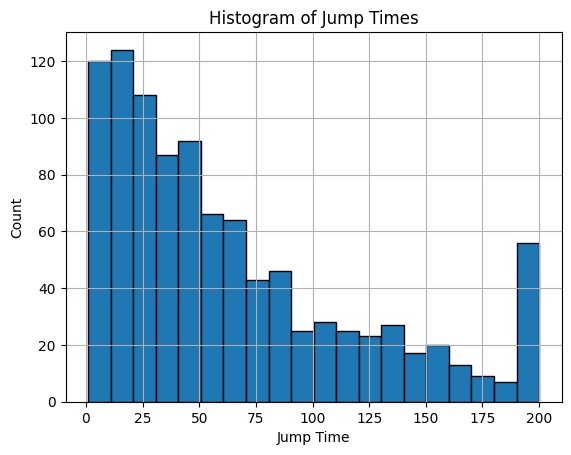

=== Exact r+1-State HMM ===


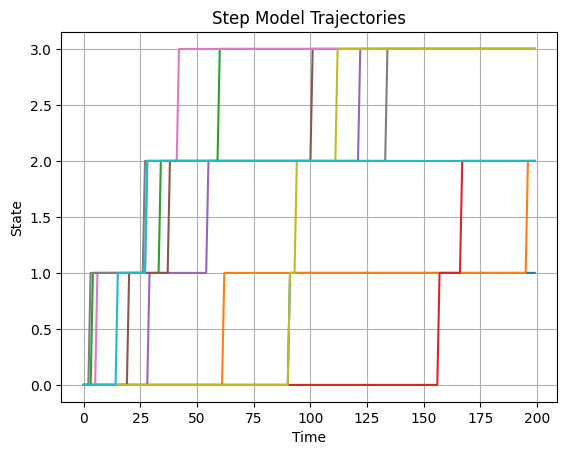

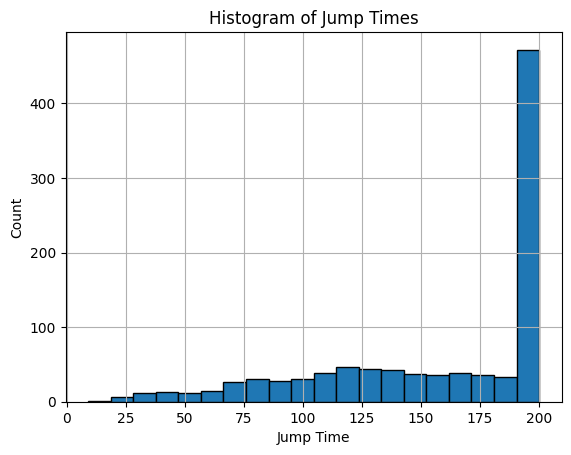

In [22]:
if __name__ == "__main__":
    m, r, T = 200, 3, 200

    print("=== Two-State HMM ===")
    step_model = StepModelHMM(m=m, r=r, T=T, exact=False)
    trajs, jumps = step_model.simulate(n_trials=1000)
    step_model.plot_trajectories(trajs[:10])
    step_model.plot_jump_histogram(jumps)

    print("=== Exact r+1-State HMM ===")
    exact_model = StepModelHMM(m=m, r=r, T=T, exact=True)
    trajs, jumps = exact_model.simulate(n_trials=1000)
    exact_model.plot_trajectories(trajs[:10])
    exact_model.plot_jump_histogram(jumps)


# Task 2.3

## Task 2.3: Inference of Hidden States

### Theory

From this point onward, we work exclusively with **discrete-state HMM versions** of the ramp and step models. We'll focus on **inference** of hidden states $ s_t $, given spike observations $ n_{1:T} $.

We use the **Forward-Backward Algorithm (FBA)** via the `hmm_expected_states` function (provided in `inference.py`) to compute:
- The **posterior probabilities**: $ P(s_t | n_{1:T}) $
- The **log-likelihood** (also called the *normalizer*): $ \log P(n_{1:T}) $

This requires:
- A 2D array `ll` of **log-likelihoods**:
  $$
  \texttt{ll}[t, s] = \log P(n_t \mid s_t = s)
  $$
  which can be calculated using `inference.poisson_logpdf`.

---

### Goal

Use this inference method to estimate:
- For the **ramp model**: $ \mathbb{E}[x_t \mid n_{1:T}] $
- For the **step model**: $ P(s_t = \text{upper level} \mid n_{1:T}) $

Compare inferred trajectories to ground truth across different model parameters.

---

## Task Plan

### Step 1: Simulate Trials
- Generate latent state trajectories $ s_t $ using the discrete-state HMM versions of the ramp and step models
- From the corresponding firing rates $ r_t $, sample spike counts $ n_t \sim \text{Poisson}(r_t) $

### Step 2: Compute Log-Likelihood Array
- Use `inference.poisson_logpdf` to compute `ll[t, s]` for all states and time steps

### Step 3: Run Inference
- Use `hmm_expected_states(ll, T_mat)` to compute:
  - Posterior $ P(s_t \mid n_{1:T}) $
  - Log-likelihood $ \log P(n_{1:T}) $

### Step 4: Ramp Model Inference
- Compute posterior expected firing rate:
  $$
  \mathbb{E}[x_t \mid n_{1:T}] = \sum_s x_s \cdot P(s_t = s \mid n_{1:T})
  $$
- Plot:
  - True $ x_t $
  - Posterior estimate $ \mathbb{E}[x_t \mid n_{1:T}] $
- Vary model parameters $ x_0, R_h $, and assess when inference is more or less accurate

### Step 5: Step Model Inference
- Estimate the probability of being in the high-rate state: $ P(s_t = \text{high} \mid n_{1:T}) $
- Plot:
  - Posterior probability
  - True jump time (vertical line)
  - Inferred jump time (e.g., first time posterior exceeds 0.5)
- Repeat for different values of $ r $ and assess inference performance

### Step 6: Filtering vs Smoothing
- Run `hmm_expected_states(..., filter=True)` to compute:
  - $ P(s_t \mid n_{1:t}) $: *Filtering*
  - Compare with smoothing $ P(s_t \mid n_{1:T}) $
- Comment on differences in:
  - Accuracy
  - Reactivity
  - Practical use in real-time systems

### Step 7: Error Quantification
- For the ramp model:
  - Compute average error: $ \frac{1}{T} \sum_t \left| \hat{x}_t - x_t \right| $
- For the step model:
  - Estimate jump time: $ \hat{\tau} = \min \{ t \mid P(s_t = \text{high}) > 0.5 \} $
  - Compare with true jump time
- Visualize with heatmaps or contour plots using `matplotlib.tricontourf`
  - Plot error as a function of two parameters (e.g. $ x_0 $ vs $ R_h $, or $ m $ vs $ r $)

---
### Notes
- Use the `discrete-state HMM` models only
- First run JIT-compiled functions (like `hmm_expected_states`) on small test cases for faster compilation
- Install [Numba](https://numba.readthedocs.io/en/stable/user/installing.html) if running locally

---
### References
- [Negative Binomial distribution – Wikipedia](https://en.wikipedia.org/wiki/Negative_binomial_distribution)
- [FBA notes notebook](https://github.com/ahmadianlab/gg3_nda/blob/main/fwdbwd.ipynb)


In [23]:

import numpy as np
import matplotlib.pyplot as plt
from inference import hmm_expected_states, poisson_logpdf


class HMMInference:
    def __init__(self, model, T_mat, x_vals):
        """
        model: instance of the discrete ramp/step model (for simulation)
        T_mat: transition matrix of the Markov chain
        x_vals: array of x values corresponding to hidden states
        """
        self.model = model
        self.T_mat = T_mat
        self.x_vals = x_vals

    def simulate_trial(self, T, seed=None):
        """Simulate latent states, rates, and Poisson spike counts."""
        if seed is not None:
            np.random.seed(seed)
        s_traj, x_traj, rates = self.model.simulate_latent(T)
        spikes = np.random.poisson(rates)
        return s_traj, x_traj, rates, spikes

    def run_inference(self, spikes):
        """Run forward-backward to compute posterior and log-likelihood."""
        ll = poisson_logpdf(spikes, self.x_vals)
        posteriors, log_likelihood = hmm_expected_states(ll, self.T_mat)
        return posteriors, log_likelihood

    def expected_xt(self, posteriors):
        """Compute E[x_t | n_{1:T}] from posteriors."""
        return np.sum(posteriors * self.x_vals[np.newaxis, :], axis=1)

    def plot_ramp_inference(self, xt_true, xt_est, title='Ramp Inference'):
        """Plot ground truth and estimated xt."""
        plt.figure(figsize=(8, 4))
        plt.plot(xt_true, label='True $x_t$', linewidth=2)
        plt.plot(xt_est, label='Inferred $\mathbb{E}[x_t | n_{1:T}]$', linestyle='--')
        plt.xlabel('Time')
        plt.ylabel('$x_t$')
        plt.legend()
        plt.title(title)
        plt.tight_layout()
        plt.show()

    def plot_step_inference(self, s_true, posteriors, high_state, title='Step Inference'):
        """Plot true jump and inferred probability of high state."""
        P_high = posteriors[:, high_state]
        jump_time = np.argmax(s_true == high_state)
        est_jump = np.argmax(P_high > 0.5)

        plt.figure(figsize=(8, 4))
        plt.plot(P_high, label='Posterior P(high)', linewidth=2)
        plt.axvline(jump_time, color='green', linestyle='--', label='True jump')
        plt.axvline(est_jump, color='red', linestyle=':', label='Estimated jump')
        plt.xlabel('Time')
        plt.ylabel('Probability')
        plt.title(title)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def compute_average_ramp_error(self, xt_true, xt_est):
        """Mean absolute error over time."""
        return np.mean(np.abs(xt_true - xt_est))

    def compute_jump_error(self, s_true, posteriors, high_state):
        """Difference in true vs inferred jump times."""
        true_jump = np.argmax(s_true == high_state)
        inferred_jump = np.argmax(posteriors[:, high_state] > 0.5)
        return np.abs(inferred_jump - true_jump)


<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_94523/625045149.py:39: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(xt_est, label='Inferred $\mathbb{E}[x_t | n_{1:T}]$', linestyle='--')


In [24]:
if __name__ == "__main__":
    params = dict(beta=0.2, sigma=0.2, dt=0.01, K=100, x0=0)
    ramp_model = DiscreteRampHMM(**params)
    x_vals = ramp_model.x_vals
    T_mat = ramp_model.T_mat

    inference = HMMInference(ramp_model, T_mat, x_vals)
    s_traj, x_traj, _, spikes = inference.simulate_trial(T=100)

    # Run inference
    posteriors, _ = inference.run_inference(spikes)
    xt_est = inference.expected_xt(posteriors)

    # Plot
    inference.plot_ramp_inference(x_traj, xt_est)

    # Error
    err = inference.compute_average_ramp_error(x_traj, xt_est)
    print(f"Mean absolute error: {err:.3f}")



AttributeError: 'DiscreteRampHMM' object has no attribute 'x_vals'

In [ ]:
# inference_grid_search.py

import numpy as np
from models import RampHMMModel, StepHMMModel
#from inference_pipeline import HMMInference
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from tqdm import tqdm


def run_ramp_grid(x0_vals, Rh_vals, T=100, n_trials=5):
    results = []

    for x0 in tqdm(x0_vals, desc="x0 loop"):
        for Rh in Rh_vals:
            errors = []
            for seed in range(n_trials):
                # Set up model
                model = RampHMMModel({'x0': x0, 'Rh': Rh})
                inference = HMMInference(model, model.T_mat, model.x_vals)

                # Simulate + infer
                s_traj, x_traj, _, spikes = inference.simulate_trial(T, seed)
                posteriors, _ = inference.run_inference(spikes)
                xt_est = inference.expected_xt(posteriors)

                # Error
                err = inference.compute_average_ramp_error(x_traj, xt_est)
                errors.append(err)

            results.append((x0, Rh, np.mean(errors)))

    return np.array(results)


def run_step_grid(p_vals, Rl_vals, Rh_vals, high_state_index, T=100, n_trials=5):
    results = []

    for p in tqdm(p_vals, desc="p loop"):
        for Rl in Rl_vals:
            for Rh in Rh_vals:
                errors = []
                for seed in range(n_trials):
                    # Set up model
                    model = StepHMMModel({'p': p, 'Rl': Rl, 'Rh': Rh})
                    inference = HMMInference(model, model.T_mat, model.x_vals)

                    # Simulate + infer
                    s_traj, _, _, spikes = inference.simulate_trial(T, seed)
                    posteriors, _ = inference.run_inference(spikes)

                    # Jump time error
                    err = inference.compute_jump_error(s_traj, posteriors, high_state_index)
                    errors.append(err)

                results.append((p, Rl, Rh, np.mean(errors)))

    return np.array(results)


In [ ]:
def plot_tricontour(data, x_idx, y_idx, z_idx, xlabel, ylabel, title):
    x = data[:, x_idx]
    y = data[:, y_idx]
    z = data[:, z_idx]

    triang = tri.Triangulation(x, y)
    plt.figure(figsize=(8, 6))
    plt.tricontourf(triang, z, cmap='viridis')
    plt.colorbar(label='Inference Error')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [ ]:
# Ramp model grid run
x0_vals = np.linspace(0.1, 0.9, 5)
Rh_vals = np.linspace(0.5, 2.0, 5)

ramp_results = run_ramp_grid(x0_vals, Rh_vals)
plot_tricontour(ramp_results, 0, 1, 2, 'x0', 'Rh', 'Ramp Inference Error')

# Step model grid run (e.g. p: jump prob, Rl/Rh: rates)
p_vals = np.linspace(0.01, 0.3, 5)
Rl_vals = [5, 10]
Rh_vals = [20, 40]
high_state_index = 1  # assuming index 1 corresponds to upper state

step_results = run_step_grid(p_vals, Rl_vals, Rh_vals, high_state_index)
# You can slice/filter this 3D result if needed for cleaner plots


In [26]:
#from models import DiscreteRampHMM
#from inference_pipeline import HMMInference

# Parameters for the discrete ramp model
params = {
    'beta': 0.5,
    'sigma': 0.1,
    'dt': 0.01,
    'K': 50,
    'x0': 0.2
}

# Create the ramp model
ramp_model = DiscreteRampHMM(**params)
x_vals = ramp_model.grid
T_mat = ramp_model.T

# Create the inference pipeline
inference = HMMInference(ramp_model, T_mat, x_vals)

# Simulate one trial: latent states, x_t, spike counts
T = 100
# Simulate a latent trajectory (x_t) using the ramp HMM
x_traj = ramp_model.simulate_trajectory(T)

# (Optional) Map x_t to spike rates r_t, and then sample spike counts from Poisson
Rh = 2
r_traj = Rh * x_traj  # Example: Rh is the high firing rate parameter
spikes = np.random.poisson(r_traj)


# Run inference (forward-backward algorithm)
posteriors, log_likelihood = inference.run_inference(spikes)

# Estimate E[x_t | n_{1:T}]
xt_est = inference.expected_xt(posteriors)

# Plot ground truth vs inference
inference.plot_ramp_inference(x_traj, xt_est)

# Compute average error
err = inference.compute_average_ramp_error(x_traj, xt_est)
print(f"Mean absolute error: {err:.3f}")


TypeError: hmm_expected_states() missing 1 required positional argument: 'll'